<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/110_intro_prob.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>


(intro_prob_notebook)=
# Introduzione al calcolo delle probabilità

In questo capitolo, esamineremo alcuni concetti generali e fondamentali che sono cruciali per una  comprensione dei metodi bayesiani. Ulteriori concetti legati alla probabilità verranno introdotti o approfonditi nei capitoli successivi, a seconda delle necessità. Tuttavia, per uno studio dettagliato della teoria delle probabilità, consiglio vivamente il libro "Introduction to Probability" di Blitzstein e Hwang (2019).

Nel corso di questo capitolo, esploreremo varie concezioni della probabilità, tra cui la visione classica, frequentista e bayesiana. Approfondiremo anche argomenti come le variabili casuali, le funzioni di massa di probabilità e le funzioni di ripartizione. Inoltre, introdurremo la simulazione con Python per una migliore comprensione della legge dei grandi numeri, un concetto fondamentale nell'ambito della probabilità.

Prima di procedere, è essenziale leggere l'appendice dedicata al {ref}`combinatorics-notebook` per ulteriori informazioni.

:::{admonition} Obiettivi di apprendimento
:class: tip

Dopo la lettura di questo capitolo, gli studenti saranno in grado di:

- Distinguere tra le varie interpretazioni della probabilità.
- Applicare correttamente gli assiomi della probabilità.
- Comprendere e interpretare i concetti di funzione di massa di probabilità e di funzione di ripartizione.
- Avere una chiara comprensione della legge dei grandi numeri.
:::

## Preparazione del Notebook

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import itertools as it
import math
import random
import scipy.stats as stats
import arviz as az
import seaborn as sns
from collections import Counter

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## Storia della probabilità

La probabilità è un modo formale di quantificare l'incertezza, assegnando plausibilità o credibilità a un insieme di possibilità mutuamente esclusive o risultati di un esperimento o osservazione. La storia della probabilità è lunga e complessa, come illustrato in varie opere (Tabak 2004, Stigler 1986, Weisberg 2014). L'origine della probabilità moderna risale a una domanda posta da Antoine Gombaud (Chevalier de Méré) a Blaise Pascal (1623–1652) su come dividere equamente le puntate di un gioco di carte interrotto. Il problema può essere così formulato (si veda la formulazione esatta su [Wikipedia](https://en.wikipedia.org/wiki/Problem_of_points)):

> Immaginiamo due persone che partecipano a un gioco a più round. In ogni round, entrambe le persone hanno la stessa probabilità di vincere. La prima persona che vince sei round consecutivi si aggiudicherà un ricchissimo premio in denaro. Ora, supponiamo che A e B abbiano già disputato sei round, con A che ha vinto cinque volte e B una volta. In quel momento, il gioco è stato interrotto a causa di un temporale. Poiché né A né B hanno raggiunto le sei vittorie, anziché assegnare il premio a uno di loro, hanno deciso di dividerlo. Ma qual è il modo più equo per farlo?

La discussione tra Pierre de Fermat (1607–1655) e Pascal ha portato alla formalizzazione dell'utilizzo della matematica per risolvere questo problema. In sostanza, una soluzione proposta consiste nel considerare le probabilità di vincita di ciascun giocatore. Ad esempio, se A ha una probabilità del 97% di vincere il premio alla fine e B ha una probabilità del 3%, allora sembrerebbe equo assegnare ad A il 97% del premio. L'interesse pubblico per la loro corrispondenza è sopravvissuto grazie al libro di Christian Huygens del 1657 "De Ratiociniis in Ludo Aleae" (Sul Ragionamento nei Giochi di Dadi), che è rimasto il riferimento per la probabilità per circa 50 anni.

Il libro postumo di Jacob Bernoulli, "L'Arte della Congettura" (1713), ha segnato una svolta nella storia della probabilità. Bernoulli ha definito la probabilità come un indice di incertezza compreso tra 0 e 1 e ha collegato il calcolo della probabilità ai dati e alla frequenza a lungo termine di un evento, noto come legge dei grandi numeri. Bernoulli ha applicato la probabilità anche a settori diversi dal gioco d'azzardo, come la mortalità umana e la giustizia penale, creando la cosiddetta "probabilità soggettiva".

### Collegamento tra Probabilità e Statistica

Durante gli anni '20 del Novecento, un momento cruciale nella storia della probabilità si è verificato con i contributi di Ronald A. Fisher, il quale ha proposto un nuovo framework teorico per l'inferenza statistica, fondato sulla concettualizzazione della frequenza. Fisher ha introdotto concetti chiave come la massima verosimiglianza, i test di significatività, i metodi di campionamento, l'analisi della varianza e il design sperimentale. Questo lavoro ha rappresentato una pietra miliare fondamentale nella teoria e nelle metodologie statistiche.

Successivamente, negli anni '30, Jerzy Neyman e Egon Pearson hanno ulteriormente avanzato il campo con lo sviluppo di una teoria della decisione statistica, basata sul principio della verosimiglianza e sull'interpretazione frequentista della probabilità. Essi hanno definito due tipologie di errori decisionali e hanno utilizzato il test di significatività di Fisher, interpretando i valori p come indicatori di tassi di errore a lungo termine.

### La riscoperta dei metodi Monte Carlo Markov chain negli anni '80

Fisher ha assunto una prospettiva critica nei confronti della "probabilità inversa" (ossia, i metodi bayesiani), nonostante questa fosse stata la metodologia predominante per l'inferenza statistica per quasi un secolo e mezzo. Il suo approccio frequentista ha avuto un profondo impatto sullo sviluppo della statistica sia teorica che sperimentale, contribuendo a un decremento nell'utilizzo dell'inferenza basata sul metodo della probabilità inversa, originariamente proposto da Laplace.

Contemporaneamente, il libro di Harold Jeffreys del 1939, intitolato "Theory of Probability", ha rappresentato una delle prime esposizioni moderne dei metodi bayesiani. Tuttavia, la rinascita del framework bayesiano è stata rinviata fino alla scoperta dei metodi Monte Carlo Markov chain alla fine degli anni '80. Questi ultimi hanno reso fattibile il calcolo di risultati precedentemente non ottenibili, consentendo così un rinnovato interesse e sviluppo nei metodi bayesiani. Per una storia dell'approccio bayesiano, si veda [Bayesian Methods: General Background](https://bayes.wustl.edu/etj/articles/general.background.pdf) oppure [Philosophy of Statistics](https://plato.stanford.edu/entries/statistics/).

## Che cos'è la probabilità?

Esistono due punti di vista relativi al significato del concetto di probabilità.

- Secondo una prospettiva che possiamo chiamare "ontologica", la probabilità è considerata come una proprietà intrinseca del mondo, indipendente dalla nostra esperienza. In questa visione, la probabilità è vista come una caratteristica oggettiva del mondo stesso.
- D'altra parte, la prospettiva "epistemica" vede la probabilità come una misura della nostra conoscenza del mondo anziché una proprietà oggettiva. Questa visione soggettiva della probabilità dipende dalla nostra conoscenza e dal nostro punto di vista.

### Interpretazione classica

La prima definizione di probabilità è stata proposta da Pierre-Simon Laplace (1749-1827), che si è avvalso del calcolo combinatorio. Secondo Laplace, la probabilità $P$ di un evento è definita come il rapporto tra il numero di casi in cui l'evento si verifica e il numero totale di casi possibili. In questa definizione, un evento è qualcosa a cui è possibile assegnare un valore di verità, ovvero qualcosa che può essere vero o falso. Ad esempio, la probabilità di ottenere un 3 in un lancio di un singolo dado è 1/6 ≃ 0.17, poiché c'è un solo caso favorevole (il lancio ha prodotto un 3) su sei casi possibili (i numeri da 1 a 6). Tuttavia, questa definizione è insoddisfacente in quanto si basa sull'assunzione che ogni evento sia equiprobabile, il che non è sempre vero. Inoltre, questa definizione è circolare poiché per definire il concetto di probabilità, è necessario prima definire cosa significa che gli eventi siano equiprobabili, e quindi si deve già conoscere il concetto di probabilità.

### Interpretazione frequentista

Un secondo tentativo di definire la probabilità si basa sull'approccio frequentista, che può essere attribuito a molti autori. In questo approccio, la probabilità è definita sulla base delle frequenze osservate dell'occorrenza di un evento. Questo approccio nasce dalla difficoltà di assegnare una probabilità agli eventi assumendo il principio di equiprobabilità, come nel caso delle monete, dei dadi o delle carte di un mazzo. Sebbene la probabilità di ottenere testa come risultato del lancio di un dado sia 1/2 se crediamo che la moneta sia bilanciata, se così non fosse non potremmo assegnare la stessa probabilità a tutti i risultati possibili. Tuttavia, possiamo stimare le probabilità come la frequenza $f_t$, definita come il rapporto tra il numero di volte in cui un lancio ha prodotto "testa" e il numero totale di lanci.

Si osservi che l'osservazione della frequenza $f_t$ è solo un' approssimazione della probabilità, ma l'accuratezza migliora all'aumentare del numero totale di lanci, $N$. In linea di principio, la probabilità di ottenere "testa", $P(T)$, è il limite della frequenza $f_t$ quando il numero totale di lanci $N$ tende all'infinito. Tuttavia, questa definizione richiede l'infinita ripetizione di un esperimento, il che può essere impraticabile o impossibile in molti casi. Inoltre, questa definizione assume che gli eventi futuri siano simili agli eventi passati, il che non è sempre garantito.

```{note}
La definizione frequentista di probabilità può essere chiarita dalla seguente simulazione.

La funzione `coin_flips` accetta due parametri: `n`, che specifica il numero di volte che una moneta viene lanciata, e `run_label`, che serve a identificare il particolare set di lanci (o "run") quando i dati vengono aggregati o analizzati successivamente. 

1. **Generazione dell'array `heads`**:
    - `np.random.binomial(1, 0.5, n)`: Questa chiamata genera un array di lunghezza `n`, dove ogni elemento è il risultato di un esperimento binomiale con un solo tentativo (indicato dal primo parametro `1`, che significa "1 prova per esperimento") e una probabilità di successo del 50% (indicato dal secondo parametro `0.5`, che rappresenta la probabilità di ottenere "testa" in un singolo lancio di moneta). Il risultato è un array dove ogni elemento è `0` (rappresentante "croce") o `1` (rappresentante "testa"), simulando così `n` lanci di una moneta.

2. **Calcolo della proporzione cumulativa di teste**:
    - `np.arange(1, n + 1)`: Questa funzione crea un array che inizia da `1` e termina a `n` (incluso). Questo array rappresenta il numero sequenziale di ogni lancio. Per esempio, se `n = 1000`, questo genera un array che va da `1` a `1000`.
    - `np.cumsum(heads)`: Calcola la somma cumulativa degli elementi dell'array `heads`. In altre parole, per ogni posizione nell'array, calcola la somma di tutti gli elementi fino a quella posizione. Questo ci dà il numero totale di teste accumulato fino a ciascun punto nell'array di lanci.
    - `proportion_heads = np.cumsum(heads) / flips`: Divide ogni elemento della somma cumulativa per il suo corrispondente indice di lancio. Questo calcola la proporzione di teste fino a quel punto specifico del numero totale di lanci. Ad esempio, dopo i primi 100 lanci, se ci sono stati 53 teste, la proporzione al 100° lancio sarà 53/100 = 0.53.

In sintesi, la funzione simula il lancio di una moneta `n` volte, calcolando la proporzione di volte che esce testa in rapporto al numero totale di lanci, man mano che il numero di lanci aumenta. Questo è utile per dimostrare la Legge dei grandi numeri, secondo cui, man mano che il numero di tentativi in un esperimento casuale aumenta, la proporzione media degli esiti tende a stabilizzarsi intorno alla probabilità teorica (in questo caso, 0.5 per una moneta equilibrata).

La linea di codice `df = pd.concat([coin_flips(n, f'run{i+1}') for i in range(4)], axis=0)` utilizza la funzione `pd.concat` di pandas per concatenare insieme i DataFrame generati da multiple chiamate alla funzione `coin_flips`, creando così un unico DataFrame che contiene i risultati di tutti i lanci di moneta suddivisi per run. 

1. **List comprehension**: `[coin_flips(n, f'run{i+1}') for i in range(4)]`
   - Questa espressione genera una lista di DataFrame. La funzione `coin_flips` viene chiamata quattro volte (poiché `range(4)` genera i numeri 0, 1, 2, 3), ciascuna con un parametro `n` che indica il numero di lanci per run e un `run_label` unico (`f'run{i+1}'`) che serve a identificare il run specifico. Per esempio, per i = 0, il `run_label` sarà `run1`, per i = 1 sarà `run2`, e così via fino a `run4`.
   - Ogni chiamata a `coin_flips` restituisce un DataFrame con tre colonne: `flips`, `proportion_heads`, e `run`, dove `run` è il label specificato (ad esempio, `run1`, `run2`, ecc.).

2. **Funzione `pd.concat`**:
   - `pd.concat([...], axis=0)` prende la lista di DataFrame generati e li concatena lungo l'asse 0, cioè uno sotto l'altro. Di default, `pd.concat` opera lungo l'asse 0, che è l'asse verticale, quindi aggiunge i DataFrame uno sotto l'altro mantenendo le stesse colonne. 
   - Il risultato è un unico DataFrame che combina i dati di tutti e quattro i runs. Ogni run mantiene le sue etichette originali nella colonna `run`, consentendo di distinguere i dati di ciascun run all'interno del DataFrame combinato.

In pratica, questo significa che se ogni chiamata a `coin_flips` genera un DataFrame con `n` righe, il DataFrame risultante da `pd.concat` avrà `4 * n` righe, con i dati di ogni run contrassegnati correttamente. Questo è particolarmente utile per l'analisi o la visualizzazione aggregata dei dati, permettendo, per esempio, di tracciare le proporzioni cumulate di teste per ogni run in un unico grafico, facilitando il confronto tra i runs.

In conclusione, l'analisi svolta tramite simulazione dimostra che, all'aumentare del numero di esperimenti condotti, la frequenza relativa si avvicina progressivamente al valore reale della probabilità utilizzata nel processo generativo dei dati.

```

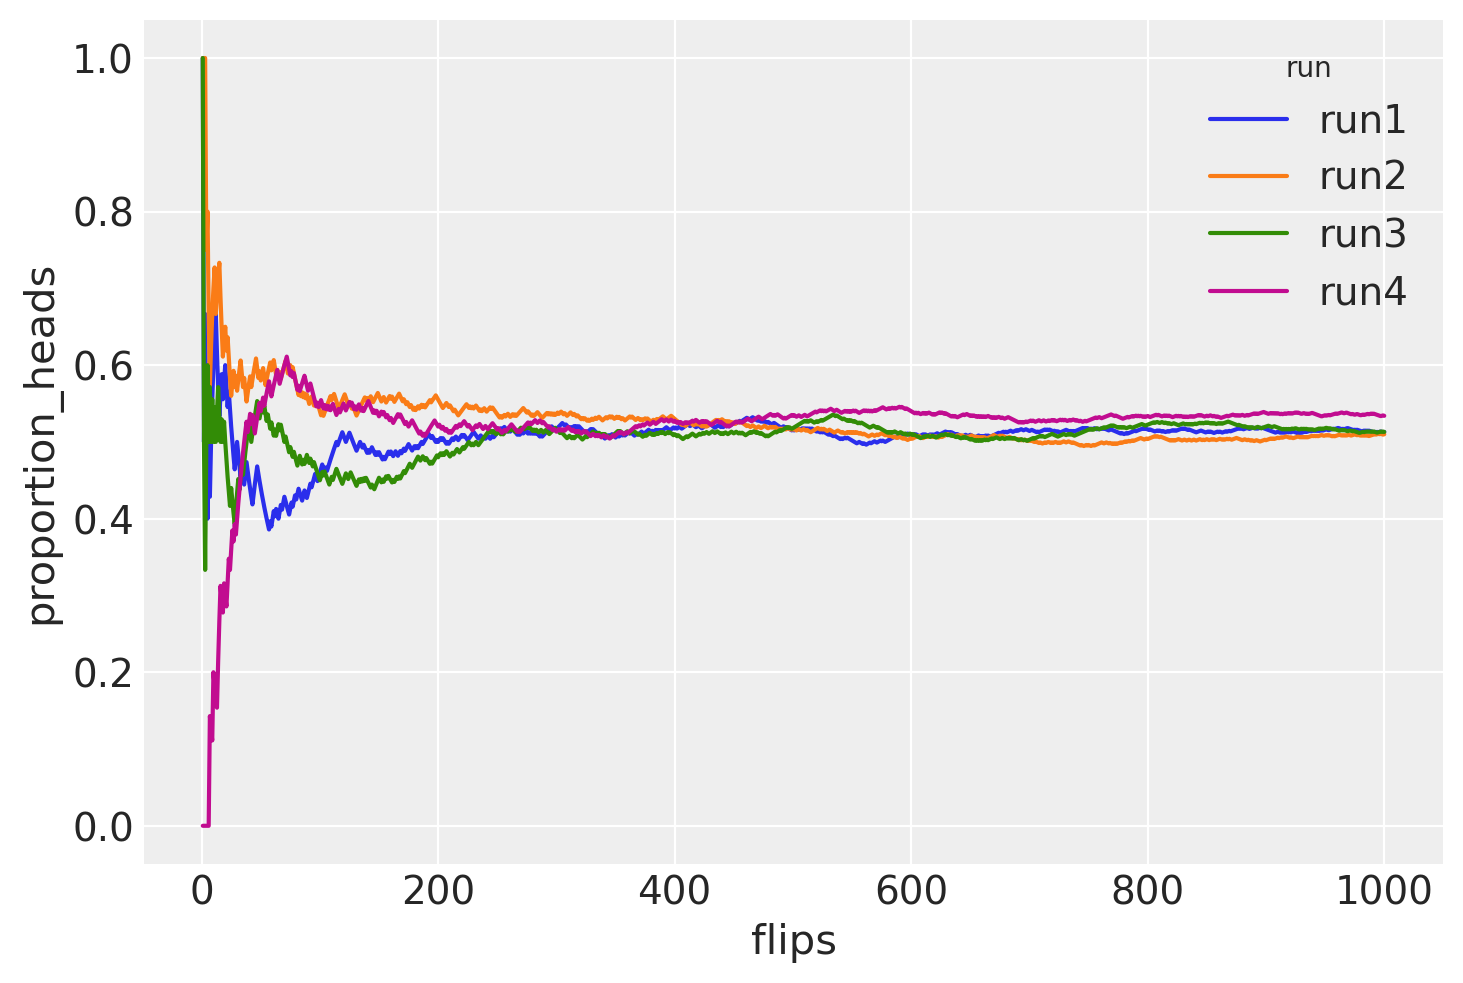

In [3]:
def coin_flips(n, run_label):
    # Genera un array di 0 e 1 dove 1 rappresenta 'testa' e 0 'croce'
    # usando una distribuzione binomiale.
    heads = np.random.binomial(1, 0.5, n)
    
    # Calcola la proporzione cumulativa di teste.
    flips = np.arange(1, n + 1) 
    proportion_heads = np.cumsum(heads) / flips
    
    # Crea un DataFrame per un facile accesso e visualizzazione dei dati.
    df = pd.DataFrame({'flips': flips, 'proportion_heads': proportion_heads, 'run': run_label})

    return df

n = 1000

df = pd.concat([coin_flips(n, f'run{i+1}') for i in range(4)], axis=0)
ax = sns.lineplot(data = df, x = 'flips', y = 'proportion_heads', hue = 'run')

#### Problema del caso singolo

Nell'ambito dell'approccio frequentista alla probabilità, che si basa sulla concezione di frequenze relative di eventi osservati su lunghe serie di ripetizioni, emerge un limite concettuale nel trattare la probabilità di eventi singolari, non ripetibili. Secondo questa prospettiva, infatti, non risulta rigorosamente appropriato discutere di probabilità relative a eventi unici e non replicabili nel tempo. Esempi emblematici di tali eventi includono la possibilità che Alcaraz vinca contro Djokovic nella finale di Wimbledon del 2023 o che si verifichi pioggia a Firenze nel giorno di Ferragosto del 2024. Questi scenari, essendo unici e circoscritti a un preciso momento storico, sfuggono alla logica frequentista che richiede, per definizione, la possibilità di osservazione ripetuta degli eventi per valutarne la probabilità. Nonostante ciò, nel linguaggio comune non specialistico, è comune l'uso del termine "probabilità" per riferirsi anche a tali eventi specifici e non ripetibili, evidenziando così una discrepanza tra l'uso tecnico e quello colloquiale del concetto di probabilità.

### Interpretazione soggettivista

Una visione alternativa della probabilità la considera come una credenza soggettiva. {cite:t}`de2017theory` ha proposto un'interpretazione in cui la probabilità non è vista come una caratteristica oggettiva degli eventi, ma piuttosto come una misura della credenza soggettiva, suggerendo di trattare $p(·)$ come una probabilità soggettiva. È interessante notare che de Finetti era un soggettivista radicale. Infatti, la frase di apertura del suo trattato in due volumi sulla probabilità afferma che "La probabilità non esiste", intendendo che la probabilità non ha uno status oggettivo, ma rappresenta piuttosto la quantificazione della nostra esperienza di incertezza. Riteneva che l'idea di una probabilità esterna all'individuo, con uno status oggettivo, fosse pura superstizione, paragonabile al credere in "Etere cosmico, Spazio e Tempo assoluti, ..., o Fate e Streghe...". Secondo {cite:t}`de2017theory`, "... esistono solo probabilità soggettive - cioè, il grado di credenza nell'occorrenza di un evento attribuito da una determinata persona in un dato momento con un dato insieme di informazioni." 

Come sottolineato da {cite:t}`press2009subjective`, la prima menzione della probabilità come grado di credenza soggettiva fu fatta da {cite:t}`ramsey1926truth`, ed è questa nozione di probabilità come credenza soggettiva che ha portato a una notevole resistenza alle idee bayesiane. Una trattazione dettagliata degli assiomi della probabilità soggettiva si trova in {cite:t}`fishburn1986axioms`.

La denominazione "soggettivo" legata alla probabilità potrebbe risultare infelice, poiché potrebbe suggerire un ragionamento vago o non scientifico. {cite:t}`lindley2013understanding` condivide queste riserve, proponendo l'alternativa "probabilità personale" rispetto a "probabilità soggettiva". Analogamente, {cite:t}`howson2006scientific` preferiscono utilizzare l'espressione "probabilità epistemica", che riflette il grado di incertezza di un individuo di fronte al problema trattato. In sostanza, la probabilità epistemica si riferisce all'incertezza personale riguardo a variabili sconosciute. Questa terminologia viene adottata anche nel testo di {cite:t}`kaplan2023bayesian`, fornendo un linguaggio più neutro per discutere di questi concetti.

Va inoltre notato che l'interpretazione soggettiva si adatta bene a eventi singoli, permettendo di esprimere una convinzione su eventi specifici, come la probabilità di pioggia in un dato giorno o l'esito di una competizione sportiva.

```{admonition} Nota
Per chi desidera approfondire, un'introduzione leggibile alle tematiche della definizione della probabilità nella storia della scienza è fornita nel primo capitolo del testo *Bernoulli's fallacy* {cite:p}`clayton2021bernoulli`.
```

## Concetti di base 

Esaminiamo qui di seguito alcuni concetti di base della teoria delle probabilità.

### Esperimento casuale ed eventi 

Nella teoria delle probabilità, un *esperimento casuale* è un processo o una situazione in cui il risultato non può essere previsto con certezza prima dell'esecuzione stessa dell'esperimento. Per poter analizzare in modo appropriato gli esperimenti casuali, sono fondamentali alcune nozioni chiave.

1. Il concetto di *spazio campionario* si riferisce all'insieme completo di tutti i potenziali risultati che potrebbero emergere da un esperimento casuale. Questo insieme è spesso rappresentato con il simbolo $\Omega$. Ad esempio, nel contesto di un esperimento casuale come il lancio di un dado, il nostro spazio campionario $\Omega$ sarebbe costituito da un insieme di risultati possibili: $\Omega = \{\omega_1, \omega_2, \omega_3, \omega_4, \omega_5, \omega_6\}$. Qui, ogni $\omega_i$, con $i = 1, \dots, 6$, rappresenta uno dei risultati osservabili possibili durante l'esperimento.

2. Un *evento elementare* è la rappresentazione di un singolo risultato all'interno dello spazio campionario, $\omega \in \Omega$. Questi eventi elementari costituiscono gli elementi fondamentali da cui sono composti gli altri eventi. Solitamente vengono identificati mediante simboli come $\omega_1$, $\omega_2$, e così via.

3. Un *evento* può essere descritto come un insieme di risultati all'interno dello spazio campionario e rappresenta una collezione di eventi elementari. Questo insieme può comprendere uno o più eventi elementari ed è solitamente indicato mediante simboli come $A$, $B$, e così via. Per esempio, $E = \{\omega \in \Omega : \omega \text{ è dispari}\}$.

```{admonition} Il punto di vista bayesiano
Nella statistica bayesiana, consideriamo un risultato di un esperimento casuale come una rappresentazione dello stato sottostante del mondo. Tuttavia, esiste un'incertezza intrinseca: non disponiamo di conoscenze complete su quale risultato specifico corrisponda al vero stato del mondo.

Le nostre osservazioni forniscono informazioni parziali sullo stato del mondo o sul risultato. Queste informazioni ci consentono di escludere i risultati che non sono coerenti con le nostre osservazioni. Tuttavia, anche dopo questo processo di esclusione, rimangono molteplici risultati potenziali che potrebbero ancora essere plausibili.

È qui che entra in gioco la teoria delle probabilità. L'inferenza bayesiana utilizza la teoria delle probabilità per quantificare e gestire l'incertezza residua. Ci consente di assegnare probabilità ai vari risultati plausibili, riflettendo il nostro livello di convinzione o incertezza su ciascuno di essi. In questo modo, possiamo prendere decisioni informate, fare previsioni o trarre conclusioni basate su una comprensione probabilistica del mondo.
```

Per esprimere il verificarsi di eventi congiunti (eventi "compatibili"), utilizziamo il connettivo logico "e" ($\land$) e la probabilità della loro intersezione è indicata come $P(A \cap B)$ o $P(A, B)$. Mentre per gli eventi disgiunti (eventi "incompatibili"), in cui i due eventi non possono verificarsi contemporaneamente, usiamo il connettivo logico "o" ($\lor$) e la probabilità della loro unione è $P(A \cup B) = 0$.

I valori di probabilità $P(A) = 0$ rappresentano eventi impossibili, mentre $P(A) = 1$ rappresentano eventi certi.

Per denotare la probabilità che un evento $A$ non si verifichi, possiamo usare la notazione $P(\lnot A)$ o $P(\bar{A})$, dove $P(\bar{A}) = 1 - P(A)$.

Per esemplificare, prendiamo in considerazione l'esperimento casuale del lancio di un dado. I singoli risultati elementari, rappresentati come $\omega$, sarebbero i singoli numeri, come {1}, {2}, {3}, e così via. D'altro canto, gli eventi possono essere formati da insiemi di questi risultati elementari. Per esempio, l'evento A, che rappresenta "ottenere un numero dispari," sarebbe espresso come l'insieme A = {1, 3, 5}, mentre l'evento B, che indica "ottenere un numero maggiore di 4," sarebbe rappresentato come l'insieme B = {5, 6}. Se focalizziamo la nostra attenzione sull'evento "dispari," il dado potrebbe mostrare come risultato il 3, l'1 o il 5, e ciascuno di questi risultati verificherebbe l'evento "dispari."

Si può affermare che $E_1, E_2, \ldots$ costituisce una partizione di $E$ quando:

- Gli insiemi $E_i$ sono disgiunti, ossia $E_i \cap E_j = \emptyset$ per ogni $i$ diverso da $j$,
- La loro unione è l'insieme completo $E$, ovvero $E_1 \cup E_2 \cup \ldots = E$.

### Assiomi della probabilità

Ci sono tre assiomi fondamentali della probabilità, dai quali possiamo derivare l'intera teoria delle probabilità.

```{admonition} Assiomi
:class: note
1. La probabilità di qualsiasi evento A è non negativa. In notazione matematica, possiamo esprimerlo come: $P(A) \geq 0$, dove P indica la "probabilità di" e A rappresenta l'evento.

2. La probabilità dell'intero spazio campionario è pari a 1. In altre parole, la somma delle probabilità di tutti gli eventi elementari è uguale a 1: $P(\text{spazio campionario}) = 1$.

3. Se gli eventi $A_1, A_2, \ldots, A_n$ sono mutuamente esclusivi (ovvero, non possono verificarsi contemporaneamente), allora la probabilità che almeno uno di essi si verifichi è la somma delle probabilità di ciascun evento: 
$P(A_1 \cup A_2 \cup \ldots \cup A_n) = P(A_1) + P(A_2) + \ldots + P(A_n)$.
```

Possiamo assegnare agli assimi della probabilità la seguente interpretazione intuitiva.

1. **La probabilità di qualsiasi evento è non negativa.**
   - Immaginiamo la probabilità come la possibilità che qualcosa accada, misurata su una scala da 0 a 1, dove 0 significa "impossibile che accada" e 1 significa "sicuro che accada". Quindi, dire che la probabilità di un evento è non negativa significa semplicemente che non può esserci una possibilità "inferiore all'impossibile". Anche se non sappiamo ancora se un evento accadrà di sicuro, sappiamo che la sua possibilità non è mai meno di zero.

2. **La probabilità dell'intero spazio campionario è pari a 1.**
   - L'idea di "spazio campionario" può sembrare complicata, ma è solo un termine tecnico per descrivere tutte le possibili situazioni che potrebbero accadere in un determinato contesto. Ad esempio, se lanciamo un dado, lo spazio campionario includerà tutti i possibili risultati: 1, 2, 3, 4, 5, e 6. Dire che la probabilità dello spazio campionario è pari a 1 significa che siamo certi al 100% che uno dei possibili risultati accadrà. Non c'è possibilità che esca un numero diverso da 1 a 6.

3. **La probabilità che si verifichi almeno uno di eventi mutuamente esclusivi è la somma delle loro probabilità.**
   - Quando parliamo di eventi "mutuamente esclusivi", ci riferiamo a situazioni che non possono accadere nello stesso momento. Ad esempio, se lanciamo una moneta, non può uscire contemporaneamente testa e croce. Quindi, se vogliamo sapere la probabilità che esca o testa o croce in un solo lancio, sommiamo le probabilità di ciascun evento. Dato che ogni evento (testa o croce) ha una probabilità di 1 su 2 (o 0.5), la somma delle probabilità è 1, confermando che uno dei due eventi sicuramente accadrà.

Questi principi sono i mattoni fondamentali della probabilità e ci aiutano a comprendere come misurare e lavorare con le possibilità del verificarsi di eventi diversi.

### Variabili casuali

Una variabile casuale reale è essenzialmente una funzione che collega gli esiti possibili di un esperimento (lo spazio campionario $\Omega$) a valori numerici reali. In termini matematici, si descrive come $X : \Omega \rightarrow \mathbb{R}$, dove $X$ è la variabile casuale e $\mathbb{R}$ rappresenta l'insieme dei numeri reali.

Per capire meglio, pensiamo al semplice atto di lanciare un dado. Ogni volta che lanciamo il dado, otteniamo un risultato specifico, un numero tra 1 e 6. Questi risultati sono gli esiti reali che possiamo osservare. Tuttavia, in matematica e in statistica, ci interessa analizzare tutti i possibili risultati in modo strutturato. Qui entrano in gioco le variabili casuali, trasformando questi esiti in numeri che possiamo usare nei nostri calcoli.

Ad esempio, consideriamo la variabile casuale $Y$ che rappresenta il risultato di un lancio di dado. Se decidiamo che $Y = 1$ significa che il risultato del lancio è un numero dispari (1, 3 o 5), abbiamo trasformato un'osservazione fisica (il lancio del dado) in un valore numerico che rappresenta un certo tipo di evento. Questo processo semplifica notevolmente l'analisi dei dati, permettendoci di applicare concetti matematici e statistici agli eventi del mondo reale.

Le variabili casuali sono strumenti chiave nella statistica, specialmente nella statistica bayesiana, e vengono usate in due modi principali:

1. **Modellazione delle conoscenze (osservazioni)**: Qui, le variabili casuali aiutano a quantificare e strutturare le informazioni che abbiamo, come i dati raccolti da esperimenti o studi.

2. **Modellazione delle incognite (variabili latenti, parametri, predizioni)**: In questo contesto, le variabili casuali rappresentano ciò che non sappiamo o che vogliamo prevedere, come i parametri nascosti di un modello o i futuri esiti di un esperimento.

Le variabili casuali si dividono in due categorie:

- **Discrete**: Queste variabili possono assumere solo un numero limitato di valori. Un esempio potrebbe essere il numero di libri letti in un mese. Questi valori sono distinti e contabili.

- **Continue**: Al contrario, le variabili continue possono assumere qualsiasi valore in un intervallo. Un esempio è la temperatura di un giorno, che può variare continuamente e assumere un numero infinito di valori all'interno di un dato range.

Attraverso questi concetti, le variabili casuali ci permettono di modellare e analizzare matematicamente la complessità e l'incertezza del mondo reale, fornendo un ponte tra le osservazioni empiriche e la teoria statistica.

#### Convenzioni di Notazione in Teoria della Probabilità

Nella teoria della probabilità, è usuale adottare una specifica convenzione di notazione per le variabili casuali e i loro esiti. Comunemente, si utilizzano le lettere maiuscole, come 'X', per indicare una variabile casuale, ovvero un concetto che rappresenta una serie di possibili esiti di un fenomeno aleatorio. D'altro canto, la corrispondente lettera minuscola, 'x' nel nostro esempio, è impiegata per denotare una specifica realizzazione o un esito particolare che la variabile casuale può assumere. Questa distinzione aiuta a chiarire se si sta parlando della variabile casuale nel suo insieme (X) o di un suo specifico valore (x).

Va notato che questa distinzione tra lettere maiuscole e minuscole non è sempre rigorosamente seguita in ogni area della statistica. In particolare, nelle pubblicazioni di statistica bayesiana, si può notare una certa flessibilità in questo uso.

Ulteriori convenzioni di notazione includono:

- 'X' è spesso usata per rappresentare variabili casuali non osservate, come parametri sconosciuti o variabili latenti di un modello.
- 'Y', al contrario, è generalmente riservata a variabili casuali osservate, ovvero dati che sono stati effettivamente raccolti o misurati in un esperimento.

In questo schema, 'Y' funge non solo da variabile casuale ma incarna anche il processo attraverso cui vengono generate le osservazioni. La specifica osservazione ottenuta, o realizzazione di 'Y', viene indicata con 'y'.

Importante è anche la considerazione che le variabili casuali possono estendersi oltre i semplici valori numerici scalari, potendo assumere la forma di vettori. Questo approccio, che introduce il concetto di vettori casuali, amplia le possibilità di analisi permettendo di trattare più variabili casuali contemporaneamente. Un vettore casuale è una funzione che associa gli esiti di un fenomeno aleatorio a vettori nello spazio euclideo $\mathbb{R}^n$. Ciò facilita l'esplorazione delle relazioni tra più variabili e la comprensione della struttura multidimensionale dei dati.

#### Variabili casuali multiple

Nella teoria della probabilità, le variabili casuali spesso non operano in isolamento ma in contesti dove interagiscono o si combinano tra loro. Per esemplificare, immaginiamo di avere una moneta perfettamente bilanciata e di decidere di lanciarla tre volte. Ogni lancio di questa moneta può essere descritto da una variabile casuale separata: $Y_1$, $Y_2$, e $Y_3$. Queste variabili rappresentano i risultati dei lanci individuali, e ogni lancio è considerato indipendente dagli altri. Ciò significa che l'esito di un lancio non influisce sugli esiti degli altri. Poiché la moneta è bilanciata, la probabilità di ottenere testa (che possiamo rappresentare come 1) o croce (rappresentata come 0) in ogni lancio è del 50%, dunque abbiamo $P(Y_n = 1) = 0.5$ e $P(Y_n = 0) = 0.5$, per $n$ uguale a 1, 2 o 3.

Quando combiniamo variabili casuali attraverso operazioni aritmetiche, possiamo creare nuove variabili che offrono ulteriori insight. Prendiamo, per esempio, i tre lanci della moneta bilanciata menzionati prima. Se definiamo $Y_1$, $Y_2$, e $Y_3$ come i risultati di questi lanci, possiamo introdurre una nuova variabile casuale $Z$ che rappresenta la somma dei risultati:

$$
Z = Y_1 + Y_2 + Y_3.
$$

La variabile $Z$ è un esempio di variabile casuale discreta, il che significa che può assumere solo valori interi specifici. A differenza delle variabili continue che possono assumere qualsiasi valore in un intervallo, $Z$ può solo risultare in una serie limitata di numeri interi, che nel contesto dei nostri lanci di moneta sono i possibili totali di testa ottenuti nei tre tentativi. La notazione $\mathbb{Z}$ qui è un po' fuorviante poiché sembra riferirsi all'insieme di tutti i numeri interi, ma nel contesto specifico di $Z$ come somma dei risultati di tre lanci di moneta, i valori possibili di $Z$ vanno da 0 (nessun testa in tre lanci) a 3 (testa in tutti e tre i lanci), rendendo $Z$ una variabile che riflette il numero totale di testa ottenuti.

(sec-fun-mass-prob)=
## Distribuzione di Probabilità 

Il concetto di distribuzione di probabilità è fondamentale per analizzare come le probabilità si distribuiscono tra i vari esiti possibili di una variabile casuale. Questo concetto varia a seconda che stiamo considerando variabili casuali discrete o continue.

### Variabili Casuali Discrete
Per le variabili casuali discrete, che assumono valori specifici e contabili (come il lancio di un dado), la distribuzione di probabilità è rappresentata dalla cosiddetta funzione di massa di probabilità, spesso abbreviata con $P(\cdot)$. Questa funzione attribuisce una probabilità precisa a ciascun esito possibile della variabile. Prendendo l'esempio del lancio di un dado equilibrato, se ci concentriamo sul risultato "1", la funzione di massa di probabilità potrebbe esprimersi come $P(Y = 1) = \frac{1}{6}$, indicando che, in una serie di lanci indipendenti, il risultato "1" si verificherebbe circa un sesto delle volte. Qui, la probabilità può essere interpretata in due modi principali: come una misura di credenza nella teoria bayesiana o come una frequenza di occorrenza a lungo termine nell'approccio frequentista.

### Variabili Casuali Continue
Nel caso delle variabili casuali continue, che possono assumere un'infinità di valori all'interno di un intervallo, si parla di densità di probabilità, indicata con $p(\cdot)$. Questa funzione non assegna probabilità a valori puntuali (dato che la probabilità di un singolo esatto valore è zero), ma determina la probabilità che la variabile si collochi entro un certo intervallo di valori.

### Supporto della Variabile Casuale
Il concetto di supporto di una variabile casuale si riferisce all'insieme di tutti i valori che la variabile può effettivamente assumere. Per esempio, il supporto di un dado standard a sei facce è l'insieme $\{1, 2, 3, 4, 5, 6\}$, mentre per una variabile casuale che segue una distribuzione continua, come quella gaussiana, il supporto potrebbe essere l'intero insieme dei numeri reali.

### Assegnazione di Probabilità
Per le variabili casuali discrete, è essenziale specificare la probabilità di ogni valore possibile per definire la loro distribuzione di probabilità in modo completo. Per le variabili continue, invece, ci affidiamo alla densità di probabilità per capire la probabilità che la variabile rientri in specifici intervalli di valori.

In conclusione, la distribuzione di probabilità, rappresentata attraverso la funzione di massa di probabilità per le variabili discrete o la densità di probabilità per quelle continue, è cruciale per descrivere il modo in cui le probabilità si distribuiscono tra i diversi esiti possibili di una variabile casuale, offrendo una visione completa del suo comportamento.

#### Un Esempio Pratico

Concentriamoci sul caso di una variabile casuale discreta attraverso un esperimento specifico. Immaginiamo di lanciare due dadi equilibrati, ciascuno con sei facce. Definiamo una variabile casuale $Z$, che rappresenta la somma dei valori ottenuti in ciascun lancio dei dadi. Indichiamo con $D_1$ il risultato del primo dado e con $D_2$ quello del secondo dado, quindi $Z = D_1 + D_2$.

Per analizzare questa variabile casuale, dobbiamo prima costruire lo spazio campionario associato all'esperimento. Lo spazio campionario in questo caso è l'insieme di tutte le possibili combinazioni dei risultati dei due lanci di dado. Dato che ogni dado ha sei facce, ci sono in totale $6 \times 6 = 36$ possibili esiti.

Ogni esito può essere rappresentato come una coppia ordinata (i, j), dove i e j sono i risultati dei dadi $D_1$ e $D_2$, rispettivamente. Quindi, lo spazio campionario può essere descritto come ${(1,1), (1,2), (1,3), \dots, (6,4), (6,5), (6,6)}$.

In [4]:
r = range(1, 7)
sample = [(i, j) for i in r for j in r]
print(*sample)

(1, 1) (1, 2) (1, 3) (1, 4) (1, 5) (1, 6) (2, 1) (2, 2) (2, 3) (2, 4) (2, 5) (2, 6) (3, 1) (3, 2) (3, 3) (3, 4) (3, 5) (3, 6) (4, 1) (4, 2) (4, 3) (4, 4) (4, 5) (4, 6) (5, 1) (5, 2) (5, 3) (5, 4) (5, 5) (5, 6) (6, 1) (6, 2) (6, 3) (6, 4) (6, 5) (6, 6)


In [5]:
elements_per_row = 6

for i in range(0, len(sample), elements_per_row):
    print(sample[i:i+elements_per_row])


[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6)]
[(2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6)]
[(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6)]
[(4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6)]
[(5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6)]
[(6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


Le sequenze come (1, 1), (1, 2), ecc. sono gli eventi elementari di questo esperimento casuale. Lo spazio campione di questo esperimento casuale è costituito da 36 eventi elementari:

In [6]:
len(sample)

36

Per ogni possibile combinazione (i, j) risultante dal lancio dei due dadi, la variabile casuale $Z$ assume un valore che corrisponde alla somma dei numeri i e j. Ad esempio, se i risultati dei dadi sono 3 e 4, allora $Z = 3 + 4 = 7$. Pertanto, il valore di $Z$ può variare da un minimo di 2 (ottenuto dal lancio di due 1) fino a un massimo di 12 (ottenuto dal lancio di due 6), coprendo così tutti i possibili risultati della somma dei due dadi. La distribuzione di $Z$ ci offre una panoramica sulle probabilità associate a ogni possibile somma risultante.

È importante sottolineare che l'evento $Z = u$, dove $u$ è un valore compreso tra 2 e 12, rappresenta un "evento composto". Ciò significa che può essere formato da più di un "evento elementare". Ad esempio, l'evento $Z = 2$ corrisponde esclusivamente all'evento elementare (1, 1), mentre l'evento $Z = 3$ è il risultato di due eventi elementari differenti: (1, 2) e (2, 1). La stessa logica si applica agli altri valori di $Z$, dove il numero di eventi elementari che contribuiscono a un dato evento composto $Z = u$ aumenta all'aumentare del valore di $u$. Questa caratteristica della distribuzione di $Z$ è fondamentale per comprendere e calcolare le probabilità associate ai diversi totali possibili nella somma dei due dadi.

Nel nostro esempio costruito usando Python, ogni elemento della lista `sample` è una lista di due elementi. Per trovare il valore della variabile casuale $Z$, quindi, dobbiamo sommare i due elementi di ciascuna lista. Nel primo punto campione (1, 1), il valore di $Z$ è 2:

In [7]:
sum(sample[0])

2

In corrispondenza dell'ultimo punto dello spazio campione (6, 6), il valore di $Z$ è 12:

In [8]:
sum(sample[35])

12

Creiamo ora la lista `z` che memorizza il valore assunto dalla variabile casuale $Z$ in corrispondenza di ciascun punto dello spazio campione:

In [9]:
r = range(1, 7)
sample = [(i, j) for i in r for j in r]
z = [sum(point) for point in sample]

# Arrange and print `z` in a format with 6 elements per row to reflect a 6x6 sample space
elements_per_row = 6
formatted_output = [z[i:i+elements_per_row] for i in range(0, len(z), elements_per_row)]

formatted_output

[[2, 3, 4, 5, 6, 7],
 [3, 4, 5, 6, 7, 8],
 [4, 5, 6, 7, 8, 9],
 [5, 6, 7, 8, 9, 10],
 [6, 7, 8, 9, 10, 11],
 [7, 8, 9, 10, 11, 12]]

Contiamo dunque quante volte si presenta ciascun possibile valore $Z$ nello spazio campione. 

In [10]:
# Inizializzo un dizionario per memorizzare le frequenze di ciascun valore di Z
frequenze_z = {}

# Calcolo le frequenze per ciascun valore di Z
for valore in z:
    if valore in frequenze_z:
        frequenze_z[valore] += 1
    else:
        frequenze_z[valore] = 1

frequenze_z

{2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 5, 9: 4, 10: 3, 11: 2, 12: 1}

I valori di probabilità per ciascun valore di $ z $ sono calcolati in base alla frequenza con cui quel particolare valore di $ z $ emerge all'interno dell'intero insieme dei risultati. In altre parole, per ogni valore $ z $, la probabilità corrispondente è determinata dalla proporzione di occorrenze di quel valore $ z $ nell'elenco dei risultati prodotti dall'esperimento casuale. Questo elenco rappresenta tutti i possibili valori che la variabile casuale $ Z $ può assumere, calcolati per ogni combinazione di punti nello spazio campionario dell'esperimento.

Costruire la distribuzione di massa di probabilità per la variabile casuale Z. La probabilità di ciascun valore di Z si trova dividendo la sua frequenza per il numero totale di esiti nello spazio campione.

In [11]:
# Calcoliamo il numero totale di esiti nello spazio campione
numero_totale_esiti = len(z)

# Inizializzo un dizionario per memorizzare la distribuzione di massa di probabilità di Z
distribuzione_massa_probabilita = {}

# Calcolo della distribuzione di massa di probabilità per ciascun valore di Z
for valore, frequenza in frequenze_z.items():
    distribuzione_massa_probabilita[valore] = frequenza / numero_totale_esiti

distribuzione_massa_probabilita

{2: 0.027777777777777776,
 3: 0.05555555555555555,
 4: 0.08333333333333333,
 5: 0.1111111111111111,
 6: 0.1388888888888889,
 7: 0.16666666666666666,
 8: 0.1388888888888889,
 9: 0.1111111111111111,
 10: 0.08333333333333333,
 11: 0.05555555555555555,
 12: 0.027777777777777776}

Creo un DataFrame con due colonne: i valori di Z e le associate probabilità.

In [12]:
df_distribuzione = pd.DataFrame(list(distribuzione_massa_probabilita.items()), columns=['Valore di Z', 'Probabilità'])

df_distribuzione

,Valore di Z,Probabilità
0,2,0.027778
1,3,0.055556
2,4,0.083333
3,5,0.111111
4,6,0.138889
5,7,0.166667
6,8,0.138889
7,9,0.111111
8,10,0.083333
9,11,0.055556


Possiamo usare un un grafico a barre per rappresentare la distribuzione di probabilità di $Z$.

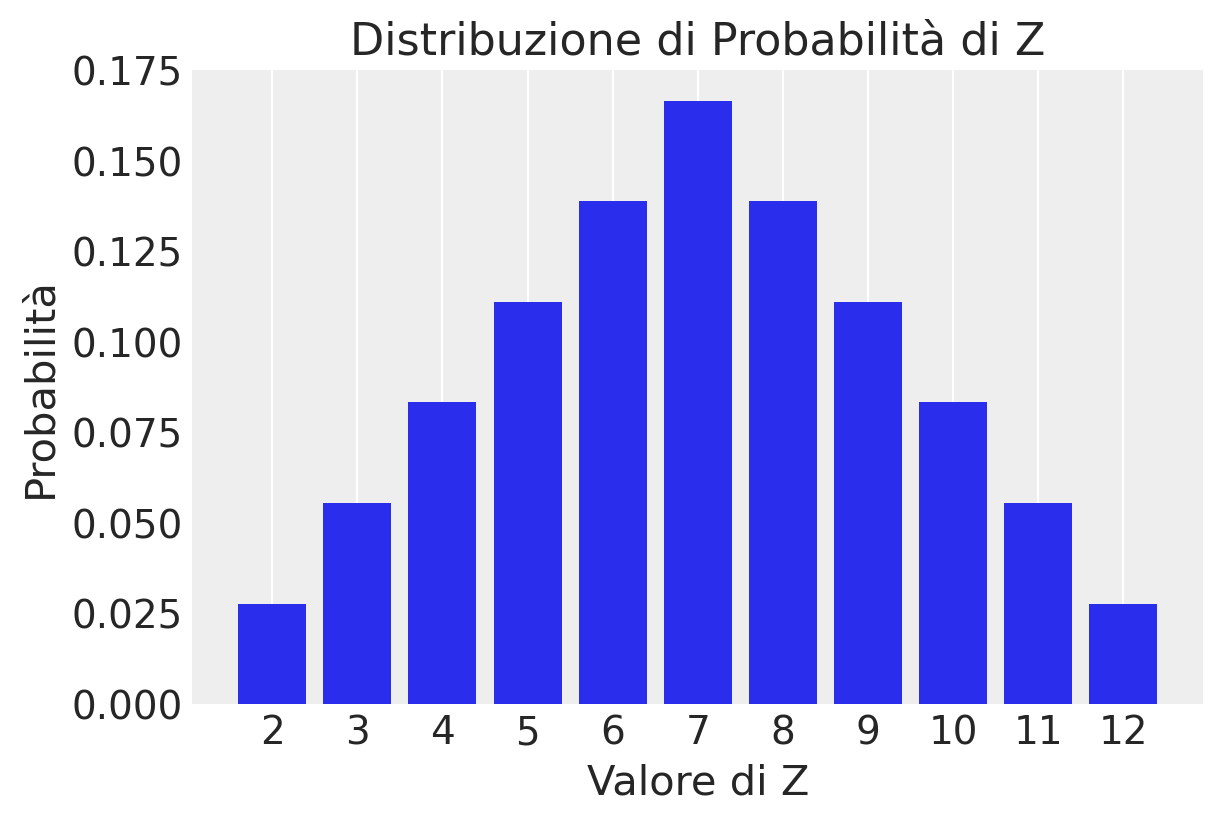

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(df_distribuzione['Valore di Z'], df_distribuzione['Probabilità'])
plt.xlabel('Valore di Z')
plt.ylabel('Probabilità')
plt.title('Distribuzione di Probabilità di Z')
plt.xticks(range(2, 13))  # Per mostrare tutte le etichette sull'asse x
plt.grid(axis='y')
plt.show()

Nel corso di questo esercizio, abbiamo calcolato le probabilità determinando il numero di casi favorevoli, cioè le occorrenze di ogni possibile somma $D_1 + D_2$, all'interno dello spazio campionario dell'esperimento di lancio di due dadi. Queste probabilità si ottengono dividendo il numero di tali occorrenze per il numero totale di combinazioni possibili nello spazio campionario. In termini formali, la probabilità di ogni valore specifico di $ Z $ è indicata come $ P_Z(z) = P(Z = z) $, dove $ P_Z(z) $ rappresenta "la probabilità che la variabile casuale $ Z $ assuma il valore $ z $". La funzione che associa a ogni valore $ u $ di $ Z $ la probabilità dell'evento $ Z = u $ è nota come *funzione di massa di probabilità* della variabile casuale $ Z $.

Questa funzione, $ p_Z $, è definita per ciascun valore possibile di $ Z $ come segue:

$$
\begin{array}{rclll}
p_Z(2) & = & 1/36, \\
p_Z(3) & = & 2/36, \\
p_Z(4) & = & 3/36, \\
p_Z(5) & = & 4/36, \\
p_Z(6) & = & 5/36, \\
p_Z(7) & = & 6/36, \\
p_Z(8) & = & 5/36, \\
p_Z(9) & = & 4/36, \\
p_Z(10) & = & 3/36, \\
p_Z(11) & = & 2/36, \\
p_Z(12) & = & 1/36. \\
\end{array}
$$

Ogni variabile casuale discreta possiede una funzione di massa di probabilità unica che rispetta le seguenti proprietà:

1. La probabilità di ogni evento singolo è compresa tra 0 e 1, ovvero $ 0 \leq P(Z=z) \leq 1 $.
2. La somma delle probabilità di tutti gli eventi possibili è pari a 1, cioè $ \sum_{z \in Z} P(Z=z) = 1 $.

Se consideriamo un sottoinsieme $ A $ della variabile casuale $ Z $, la probabilità associata a $ A $ dalla distribuzione $ P_Z $ è data da:

$$
P_Z(A) = \sum_{z \in A} P(Z = z).
$$

Per esempio, per la variabile casuale $ Z $ relativa al lancio di due dadi, la probabilità che $ Z $ sia un numero dispari si calcola sommando le probabilità dei valori dispari:

$$
\begin{align}
P(\text{"Z è un numero dispari"}) &= P_Z(3) + P_Z(5) + P_Z(7) + P_Z(9) + P_Z(11) \\
&= \frac{2}{36} + \frac{4}{36} + \frac{6}{36} + \frac{4}{36} + \frac{2}{36} \\
&= \frac{18}{36} \\
&= \frac{1}{2}.
\end{align}
$$

Questa formula ci permette di calcolare la probabilità di qualsiasi sottoinsieme di $ Z $ utilizzando la distribuzione di probabilità $ P_Z $.

### Funzione di Ripartizione per Variabili Casuali Discrete

La funzione di ripartizione di una variabile casuale discreta, come $ X $, è un mezzo per calcolare la probabilità che $ X $ assuma un valore non maggiore di un certo valore $ x $. Questa funzione, indicata con $ F(x) $, cumula progressivamente le probabilità fino a $ x $, ed è definita come:

$$
F(x_k) = P(X \leq x_k) = \sum_{x_i \leq x_k} P(x_i).
$$

In questa formula, $ F(x_k) $ è la probabilità che la variabile casuale $ X $ assuma un valore minore o uguale a $ x_k $. In altre parole, $ F(x) $ fornisce la probabilità cumulativa di $ X $ fino a un dato punto $ x $.

Per il caso del lancio di due dadi e la variabile casuale $ Z $ definita come la loro somma, la funzione di ripartizione di $ Z $ può essere illustrata come segue:

```{table}
| z   | p(z)   | F(z)     |
| --- | ------ | -------- |
| 2   | 1/36   | 1/36     |
| 3   | 2/36   | 3/36     |
| 4   | 3/36   | 6/36     |
| 5   | 4/36   | 10/36    |
| 6   | 5/36   | 15/36    |
| 7   | 6/36   | 21/36    |
| 8   | 5/36   | 26/36    |
| 9   | 4/36   | 30/36    |
| 10  | 3/36   | 33/36    |
| 11  | 2/36   | 35/36    |
| 12  | 1/36   | 36/36    |
```

In questa tabella, $ F(z) $ rappresenta la funzione di ripartizione cumulativa per ciascun valore $ z $. Questo aiuta a comprendere la distribuzione cumulativa delle probabilità per la variabile casuale $ Z $ nel contesto del lancio dei due dadi.

### Trovare la probabilità con una simulazione 

La distribuzione di probabilità che abbiamo precedentemente calcolato per il lancio dei due dadi è corretta, ma esiste un altro metodo per ottenere un risultato molto simile attraverso la simulazione. Questo metodo implica la generazione di un elevato numero di ripetizioni dell'esperimento casuale e l'analisi delle frequenze relative dei risultati ottenuti. In altre parole, simulando l'esperimento numerose volte, possiamo approssimare la distribuzione di probabilità empirica, che si avvicina sempre di più alla distribuzione teorica man mano che il numero di ripetizioni aumenta. Questo approccio è comune in statistica ed è particolarmente utile quando la distribuzione di probabilità teorica non è facilmente calcolabile o è troppo complessa per essere gestita in modo analitico.

Nel capitolo {ref}`intro-python-notebook` abbiamo visto come creare una funzione che ritorna il risultato del lancio di un dado:

In [14]:
def roll_die():
    """
    returns a random int between 1 and 6
    """
    return rng.choice([1, 2, 3, 4, 5, 6])

Possiamo ora definire una funzione che ritorna la somma dei punti prodotti dal lancio di due dadi. La funzione ha come argomento il numero di ripetizioni di questo esperimento casuale.

In [15]:
def roll_two_dice(n):
    """
    returns a random int between 2 and 12
    """
    rolls = []
    for i in range(n):
        two_dice = roll_die() + roll_die()
        rolls.append(two_dice)
    
    return rolls

Eseguiamo 100,000 ripetizioni dell'esperimento casuale e memorizzo i risultati ottenuti.

In [16]:
nrolls = 100000
res = roll_two_dice(nrolls)
print(*res[1:20])

7 9 6 3 10 10 10 5 9 7 8 9 8 7 5 5 7 11 6


Creiamo un DataFrame che contiene la variabile `y` corrispondente ai risultati delle 10,000 ripetizioni dell'esperimento casuale.

In [17]:
df = pd.DataFrame()
df["y"] = res 

Utilizziamo dunque il metodo `value_counts()`, che può essere applicato a un DataFrame, come abbiamo visto nel capitolo {ref}`freq-distr-notebook`, per trovare le frequenze assolute di ciascuno dei possibili risultati dell'esperimento casuale (cioè, 2, 3, ..., 12). Dividendo per il numero totale delle ripetizioni, otterremo una stima empirica della probabilità. Si noti che i risultati saranno simili a quelli teorici ottenuti in precedenza.

In [18]:
abs_freqs = df["y"].value_counts().sort_index()
px = abs_freqs / nrolls
list(zip(list(range(2, 13)), px))

[(2, 0.0279),
 (3, 0.05467),
 (4, 0.083),
 (5, 0.11032),
 (6, 0.13932),
 (7, 0.16827),
 (8, 0.13834),
 (9, 0.11061),
 (10, 0.08499),
 (11, 0.05482),
 (12, 0.02776)]

## Distribuzioni di Probabilità e Statistica Bayesiana

La statistica bayesiana impiega le distribuzioni di probabilità come motore inferenziale per la stima dei parametri e dell'incertezza.

Immaginiamo che le distribuzioni di probabilità siano piccoli pezzi di "Lego" con cui possiamo costruire qualsiasi cosa desideriamo. Questo principio si applica analogamente ai modelli statistici bayesiani. Possiamo costruire modelli che vanno dai più semplici ai più complessi, utilizzando le distribuzioni di probabilità e le loro interrelazioni.

Una funzione di distribuzione di probabilità è una funzione matematica che fornisce le probabilità associate a differenti esiti di un esperimento. Essa offre una descrizione matematica di un fenomeno aleatorio in termini del suo spazio campionario e delle probabilità degli eventi (sottoinsiemi dello spazio campionario).

$$ P(X): X \rightarrow \mathbb{R} \in [0, 1] $$

Per le variabili aleatorie discrete, utilizziamo il termine "massa"; per quelle continue, parliamo invece di "densità".

Adottiamo la notazione
$$ X \sim \text{Dist}(\theta_1, \theta_2, \ldots), $$

dove:

- $X$: variabile aleatoria
- $\text{Dist}$: nome della distribuzione
- $\theta_1, \theta_2, \ldots$: parametri che definiscono il comportamento della distribuzione

Ogni distribuzione di probabilità può essere "parametrizzata" specificando dei parametri che permettono di controllare certi aspetti della distribuzione per un obiettivo specifico. 

Come vedremo nei capitoli successivi, è fondamentale comprendere la distinzione tra due principali categorie di distribuzioni di probabilità:

1. **Distribuzioni di Probabilità Discrete**: Queste distribuzioni caratterizzano risultati che assumono valori numerici discreti, come i numeri interi. In termini matematici, i possibili esiti possono essere espressi come $-N, \ldots, -2, -1, 0, 1, 2, \ldots, N$, dove $N \in \mathbb{Z}$. In queste distribuzioni, parliamo di "massa" di probabilità, poiché la probabilità è assegnata a punti specifici nel dominio di definizione.

2. **Distribuzioni di Probabilità Continue**: Al contrario delle distribuzioni discrete, le distribuzioni continue si occupano di esiti che cadono in un intervallo continuo di numeri reali, rappresentati matematicamente come $(-\infty, +\infty) \in \mathbb{R}$. Per queste distribuzioni, utilizziamo il termine "densità" di probabilità. A differenza delle variabili discrete, non possiamo parlare della probabilità che una variabile casuale $X$ assuma esattamente un valore $x$, poiché in un contesto continuo tale probabilità è sempre nulla. Questo avviene perché non è possibile specificare un singolo valore esatto all'interno di un continuum. Invece, consideriamo la probabilità che $X$ si collochi all'interno di un intervallo specifico $[a, b]$.

    La funzione di densità di probabilità (PDF, dall'inglese Probability Density Function) gioca un ruolo chiave in questo contesto ed è definita come segue:

    $$\text{PDF}(x) = P(a \leq X \leq b) = \int_a^b f(x) \, dx. $$

    Questo strumento matematico ci permette di calcolare la probabilità che una variabile casuale continui a prendere valori all'interno di un intervallo dato, fornendo una descrizione completa delle caratteristiche probabilistiche del fenomeno in esame.

### Il problema del compleanno

Consideriamo ora il famoso paradosso del compleanno, anche noto come problema del compleanno, che è un curioso risultato della teoria della probabilità introdotto da Richard von Mises nel 1939. Questo paradosso afferma che la probabilità che almeno due persone in un gruppo abbiano la stessa data di compleanno è notevolmente più alta di quanto ci si potrebbe aspettare intuitivamente. Ad esempio, in un gruppo di sole 23 persone, la probabilità che almeno due di loro abbiano lo stesso compleanno è di circa il 51%, mentre con 30 persone questa probabilità supera il 70% e con 50 persone raggiunge addirittura il 97%. Questo esempio mette in evidenza come le nostre intuizioni possano essere fuorvianti quando si tratta di calcolare la probabilità di eventi rari o improbabili.

La soluzione matematica al problema del compleanno è data dalla seguente formula:

$$
P(p)=1-{\frac  {364!}{365^{{p-1}}(365-p)!}},
$$

dove $P(p)$ rappresenta la probabilità che almeno due persone abbiano lo stesso compleanno in un gruppo di $p$ persone. La spiegazione dettagliata può essere trovata su Wikipedia o in altre fonti di teoria delle probabilità.

Tuttavia, esiste anche un metodo più semplice per risolvere il problema del compleanno, che consiste nell'utilizzare una simulazione. Questo approccio coinvolge la scrittura di codice per simulare un gran numero di gruppi di persone e controllare quanti di essi hanno almeno due persone con la stessa data di compleanno. Il codice di esempio può essere trovato nel libro "Introduction to Computation and Programming Using Python" di {cite:t}`guttag2021introduction` e in altre risorse. 

Questo esempio dimostra non solo il principio intuitivo che, anche in gruppi relativamente piccoli, la probabilità di coincidenza di compleanni è sorprendentemente alta, ma mostra anche come la simulazione possa essere utilizzata per approssimare probabilità complesse che altrimenti sarebbero difficili da calcolare direttamente.

Esaminiamo la funzione seguente.

In [19]:
def simulate_birthday_problem(num_people, num_same, num_trials):
    hits = 0  # Numero di volte che troviamo almeno num_same compleanni lo stesso giorno
    
    for trial in range(num_trials):
        # Creiamo una lista di 366 giorni (0 compleanni per ogni giorno)
        birthdays = [0] * 366
        
        # Generiamo i compleanni per tutte le persone
        for person in range(num_people):
            # Scegliamo un giorno a caso per il compleanno, da 0 a 365
            birth_date = random.randint(0, 365)
            # Incrementiamo il numero di compleanni per quel giorno
            birthdays[birth_date] += 1
            
        # Controlliamo se c'è almeno un giorno con num_same o più compleanni
        found = False  # Inizialmente non abbiamo trovato giorni con abbastanza compleanni
        for day in birthdays:
            if day >= num_same:
                found = True  # Abbiamo trovato un giorno con abbastanza compleanni
                break  # Interrompiamo il ciclo, non c'è bisogno di controllare gli altri giorni
        
        # Se abbiamo trovato un giorno con abbastanza compleanni, contiamo questa prova come un "hit"
        if found:
            hits += 1
            
    # Calcoliamo la probabilità stimata dividendo il numero di "hits" per il numero totale di prove
    estimated_probability = hits / num_trials
    
    # Restituiamo la probabilità stimata
    return estimated_probability

Consiseriamo con attenzione lo snippet centrale della funzione precedente.

In [20]:
random.seed(123)

num_people = 23

# Creiamo una lista di 366 giorni (0 compleanni per ogni giorno)
birthdays = [0] * 366
        
# Generiamo i compleanni per tutte le persone
for person in range(num_people):
    # Scegliamo un giorno a caso per il compleanno, da 0 a 365
    birth_date = random.randint(0, 365)
    # Incrementiamo il numero di compleanni per quel giorno
    birthdays[birth_date] += 1
    
print(*birthdays)

1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0


La logica dietro lo snippet di codice presentato sopra fa parte di una procedura per simulare la distribuzione dei compleanni in un gruppo di persone (nell'esempio sopra, 23) e viene usato per esplorare il famoso "Paradosso del compleanno". Ecco i passaggi logici:

1. **Inizializzazione di una Lista per i Compleanni**: Si inizia creando una lista (o array) che rappresenta ogni giorno dell'anno, inclusi i giorni di un possibile anno bisestile, per un totale di 366 giorni. Ogni elemento della lista tiene il conto di quanti individui hanno il compleanno in quel particolare giorno dell'anno. Inizialmente, questo conteggio è impostato a 0 per tutti i giorni, indicando che non ci sono ancora stati assegnati compleanni.

2. **Simulazione dei Compleanni**: Successivamente, si entra in una fase di simulazione dove per ogni persona nel gruppo (il numero di persone è definito dalla variabile `num_people`), si genera casualmente un giorno di compleanno. Questo è fatto selezionando un numero a caso tra 0 e 365, dove ciascun numero rappresenta un giorno dell'anno. Questo passo simula l'assegnazione di un giorno di compleanno casuale a ciascuna persona nel gruppo.

3. **Aggiornamento dei Conteggi dei Compleanni**: Dopo aver determinato casualmente il giorno di compleanno per una persona, si incrementa di 1 il conteggio dei compleanni per quel giorno specifico nella lista dei compleanni. Questo significa che si tiene traccia del numero di persone che hanno il compleanno in ciascun giorno dell'anno. L'operazione viene ripetuta per ogni persona nel gruppo, potenzialmente aumentando i conteggi per alcuni giorni più di una volta se più persone hanno il compleanno nello stesso giorno.

4. **Visualizzazione dei Risultati**: Alla fine della simulazione, si stampa il conteggio finale dei compleanni per ciascun giorno dell'anno. Questo mostra quanti individui, all'interno del gruppo simulato, hanno il loro compleanno in ogni giorno specifico dell'anno. Questo può rivelare giorni con più compleanni, supportando la discussione sul "Paradosso del compleanno" che in un gruppo relativamente piccolo di persone è sorprendentemente probabile trovare due individui che condividono lo stesso giorno di compleanno.

La logica qui illustrata è un esempio di come modelli matematici e simulazioni possano essere usati per esplorare e spiegare fenomeni controintuitivi, come il Paradosso del compleanno, in modo visivo e interattivo.

Di seguito viene utilizzata la funzione completa definita sopra per il caso di 23 persone e 10000 ripetizioni di questo processo, per determinare la probabilità che almeno due persone abbiano lo stesso compleanno.

In [21]:
num_people = 23
num_same = 2
num_trials = 10000
probability = simulate_birthday_problem(num_people, num_same, num_trials)
print(f"La probabilità stimata che in un gruppo di {num_people} persone, almeno {num_same} abbiano il compleanno lo stesso giorno è: {probability:.4f}")

La probabilità stimata che in un gruppo di 23 persone, almeno 2 abbiano il compleanno lo stesso giorno è: 0.5109


Un primo punto da notare è che, per affrontare il problema della probabilità che, in un gruppo di $n$ persone, almeno due condividano lo stesso compleanno, è essenziale seguire un approccio metodico che si divide in due fasi principali: la definizione della logica concettuale e l'implementazione computazionale.

1. **Definizione della Logica Concettuale**: La prima fase riguarda la comprensione e la definizione del problema in termini astratti. Si deve elaborare una strategia che consenta di valutare la probabilità di coincidenza dei compleanni in un insieme di $n$ individui. Questa fase include la decisione di modellare il problema attraverso una simulazione Monte Carlo, dove si riproducono numerose volte le condizioni del problema (la scelta casuale dei giorni di nascita per un dato numero di persone) per poi analizzare la frequenza con cui si verificano gli eventi di interesse (due o più persone che condividono lo stesso compleanno).

2. **Implementazione Computazionale**: La seconda fase implica la traduzione della strategia concettuale in un algoritmo eseguibile, utilizzando un linguaggio di programmazione specifico come Python. In questo contesto, si procede con la generazione di compleanni casuali per ciascun individuo nel gruppo e si tiene traccia della distribuzione dei compleanni per valutare la presenza di coincidenze. Questo richiede l'uso di strutture dati appropriate (ad esempio, un array dove ogni elemento rappresenta un giorno dell'anno e il suo valore il numero di persone nate in quel giorno) e di algoritmi per la generazione di numeri casuali. La ripetizione di questa procedura per un numero significativo di volte (simulazioni) permette di stimare la probabilità cercata.

L'efficacia della soluzione dipende dalla precisione con cui la logica concettuale è definita e dalla correttezza dell'implementazione computazionale. Mentre la fase concettuale richiede una comprensione profonda del problema e della matematica/statistica sottostante, la fase di implementazione beneficia dell'uso di strumenti informatici avanzati, inclusi i moderni ambienti di programmazione e librerie specializzate, che possono facilitare la simulazione e l'analisi dei dati. La chiave del successo risiede nell'accurata definizione del problema e nella scelta di un modello di simulazione adeguato, seguiti da un'implementazione rigorosa e metodica.

Un aspetto cruciale da considerare è che sia il calcolo analitico attraverso la formula, sia la metodologia simulativa rappresentano approcci approssimativi nel problema dei compleanni. Questo perché entrambi presuppongono una distribuzione uniforme dei compleanni lungo tutti i giorni dell'anno, ipotesi che non trova riscontro nella realtà. Tale discrepanza viene evidenziata nelle analisi empiriche, come illustrato nella figura successiva. È fondamentale, quindi, riconoscere che l'applicazione di modelli probabilistici a fenomeni empirici porta a conclusioni che mantengono la loro validità nella misura in cui le assunzioni modellistiche specchiano accuratamente le dinamiche e le peculiarità del contesto reale analizzato. Di conseguenza, le inferenze probabilistiche e le proiezioni fatte sulla base di questi modelli sono affidabili soltanto se le premesse su cui si basano sono verosimili e adeguatamente rappresentative del fenomeno sotto osservazione.

```{image} ../images/birthdays.png
:height: 500px
:align: center
```

### La Legge dei Grandi Numeri

La Legge dei Grandi Numeri rappresenta un concetto cardine nella teoria della probabilità, che dimostra come l'accuratezza nella stima della probabilità di un evento specifico, denotata come $P(Y=y)$, migliora con l'aumentare del numero di esperimenti casuali ripetuti. Per evidenziare questo principio, si può tracciare l'evoluzione della stima di probabilità ad ogni incremento nel numero di ripetizioni $m$, partendo da 1 fino a raggiungere un limite superiore $M$. Tale metodologia offre una verifica empirica dell'efficacia di questo teorema.

Il teorema afferma che all'aumentare delle ripetizioni di un esperimento casuale, la media dei risultati osservati tende a convergere al valore atteso teorico della variabile aleatoria in questione. In pratica, ciò implica che l'accuratezza della media empirica dei risultati si intensifica, avvicinandosi progressivamente al valore medio teorico delineato dalla teoria della probabilità.

L'importanza di questo principio risiede nella sua capacità di affinare la stima della probabilità di un evento attraverso un numero significativo di tentativi, rendendo la probabilità stimata progressivamente più precisa e vicina al valore teorico. Questo legame tra osservazioni empiriche e principi teorici della probabilità costituisce una garanzia essenziale per la validità dell'applicazione dei modelli probabilistici ai fenomeni reali.

Dal punto di vista statistico e inferenziale, la Legge dei Grandi Numeri è fondamentale in quanto fornisce una base solida per l'uso di modelli probabilistici nell'interpretazione di fenomeni reali. Assicura che, nonostante le fluttuazioni casuali presenti in osservazioni isolate, la tendenza a lungo termine di un ampio insieme di ripetizioni si allineerà fedelmente alle leggi della probabilità.

Formalmente, data una serie di variabili casuali indipendenti $X_1, X_2, \ldots, X_n$, ognuna con media $\mu$, la Legge dei Grandi Numeri stabilisce che:

$$
\lim_{{n \to \infty}} P\left(\left|\frac{X_1 + X_2 + \ldots + X_n}{n} - \mu\right| < \epsilon\right) = 1,
$$

dove $\epsilon$ è un valore arbitrariamente piccolo positivo e $P(\cdot)$ indica la probabilità. Questo significa che con un elevato numero di ripetizioni, la stima empirica della media campionaria si avvicinerà sempre più al valore medio teorico atteso, consentendo di fare inferenze affidabili sulla probabilità degli eventi studiati.

Un esempio pratico per illustrare la Legge dei grandi numeri è già stato fornito attraverso la simulazione che abbiamo precedentemente descritto. In quella simulazione, abbiamo generato in modo casuale numeri interi, 0 o 1, per rappresentare il risultato di ciascun lancio di una moneta (dove "0" sta per croce e "1" per testa). Abbiamo monitorato la somma cumulativa dei risultati: ogni volta che il risultato era "testa" (rappresentato dal numero 1), aggiungevamo 1 al totale, permettendoci di tenere traccia del numero totale di volte in cui è uscita testa. Abbiamo inoltre registrato il numero totale di lanci effettuati. Dopo ogni lancio, abbiamo calcolato la media, o proporzione, dei lanci risultati in testa dividendo la somma cumulativa dei risultati per il numero totale di lanci. Questa proporzione è stata poi visualizzata in un grafico, mostrando come la media si evolveva in relazione al numero crescente di lanci, fornendo così un'esemplificazione visiva di come la Legge dei grandi numeri si manifesti attraverso la ripetizione di eventi casuali.

## Commenti e considerazioni finali

In questo capitolo, abbiamo esplorato i fondamenti della teoria delle probabilità, tra cui la costruzione dello spazio campione per gli esperimenti casuali e le proprietà fondamentali della probabilità. Abbiamo imparato a calcolare le probabilità degli eventi in uno spazio campione discreto e utilizzato funzioni di ripartizione e di massa di probabilità per le variabili casuali. Inoltre, abbiamo introdotto il concetto di simulazione come metodo per approssimare le distribuzioni di probabilità empiriche quando non è possibile ottenere soluzioni analitiche.

La teoria delle probabilità è essenziale per la statistica e ha diverse applicazioni pratiche, tra cui la psicologia. Comprendere le probabilità ci consente di prendere decisioni informate in situazioni incerte e di sviluppare previsioni affidabili. Con una solida comprensione delle nozioni di base della probabilità, possiamo affrontare una vasta gamma di problemi e prendere decisioni basate sulla probabilità dei risultati possibili. Tuttavia, è fondamentale ricordare che i modelli probabilistici sono solo approssimazioni della realtà e possono essere influenzati da semplificazioni e limitazioni dei dati disponibili. Pertanto, è importante esercitare cautela nell'interpretazione dei risultati e comprendere le assunzioni alla base delle analisi.

## Esercizio

Utilizzando il file condiviso su Google Drive, ogni studente inserirà il proprio nome e la data di compleanno nel formato specificato. Successivamente, il file Excel con i dati verrà importato in Python. L'obiettivo del problema è confrontare la predizione teorica calcolata risolvendo il "paradosso del compleanno" con i dati effettivamente ottenuti dagli studenti. Questo problema ci permetterà di confrontare la teoria con i dati reali e di analizzare quanto sia probabile che ci siano studenti con compleanni uguali all'interno della classe. Di seguito, trovate un esempio di come contare il numero di compleanni uguali utilizzando il codice Python.

In [22]:
def count_same_birthdays(birthday_list):
    same_birthdays = {}
    for name, birthday in birthday_list:
        if birthday in same_birthdays:
            same_birthdays[birthday].append(name)
        else:
            same_birthdays[birthday] = [name]

    return same_birthdays


# Example input with 5 students
birthday_list = [
    ("Mario Rossi", "agosto 3"),
    ("Giovanna Bianchi", "agosto 3"),
    ("Maria Neri", "agosto 3"),
    ("Francesco Ferrari", "giugno 12"),
    ("Alice Esposito", "maggio 26"),
    ("Giovanna Romano", "giugno 12"),
    ("Maria Gallo", "agosto 3"),
]

same_birthdays = count_same_birthdays(birthday_list)

# Print shared birthdays
for birthday, students in same_birthdays.items():
    if len(students) > 1:
        print(f"Compleanno {birthday}: {', '.join(students)}")

Compleanno agosto 3: Mario Rossi, Giovanna Bianchi, Maria Neri, Maria Gallo
Compleanno giugno 12: Francesco Ferrari, Giovanna Romano


Altri esercizi sulla probabilità discreta sono proposti nell'appendice {ref}`discr-prob-appendix`.

::::{important}
Durante l'esame, sarete chiamati a dimostrare la vostra capacità di:

- Comprendere le diverse interpretazioni della probabilità.
- Conoscere e saper applicare i concetti di spazio campionario ed evento.
- Interpretare gli assiomi della probabilità.
- Comprendere il concetto di variabile casuale.
- Costruire una funzione di massa di probabilità.
- Calcolare gli eventi definiti su una funzione di massa di probabilità.
- Utilizzare la funzione di ripartizione.
- Calcolare la probabilità tramite simulazione.
- Risolvere il problema del compleanno.
- Applicare la legge dei grandi numeri tramite simulazione.
::::

## Watermark

In [23]:
%load_ext watermark
%watermark -n -u -v -iv -w -m

Last updated: Thu Mar 14 2024

Python implementation: CPython
Python version       : 3.11.8
IPython version      : 8.22.2

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

scipy     : 1.12.0
seaborn   : 0.13.2
arviz     : 0.17.0
pandas    : 2.2.1
numpy     : 1.26.4
matplotlib: 3.8.3

Watermark: 2.4.3

